# 9.10. Proyecto Integrador: Evaluación de Modelos y Riesgo Crediticio

**Autor:** Andrés Duarte Chaves  
**Programa:** Maestría en Ingenieria Biomédica
**Docente:** Dr. Lihki Rubio  

## 9.10.1. Objetivo General
Construir y comparar rigurosamente modelos de clasificación supervisada para predecir el incumplimiento de pago (**`default = 1`**, asociado a `Charged Off`) frente a la cancelación total (**`default = 0`**, asociado a `Fully Paid`) en la plataforma de préstamos peer-to-peer *Lending Club*.

El análisis evalúa las diferencias en escalabilidad, tiempos de cómputo y rendimiento predictivo entre **scikit-learn** (cómputo local multihilo) y **PySpark MLlib** (cómputo distribuido en memoria), complementando con interpretabilidad local agnóstica del modelo mediante **LIME** enfocado en los casos críticos de falsos negativos.

In [2]:
import os
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# PySpark MLlib
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.storagelevel import StorageLevel
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder as SparkOHE,
    VectorAssembler, StandardScaler as SparkScaler
)
from pyspark.ml.classification import RandomForestClassifier as SparkRF, LinearSVC as SparkLinearSVC
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Interpretabilidad Local
import lime
import lime.lime_tabular

# Estilo gráfico
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Inicialización de la sesión PySpark (Configuración balanceada para macOS Apple Silicon, 8GB RAM)
spark = SparkSession.builder \
    .appName("LendingClub_JBook_Evaluacion") \
    .master("local[4]") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.default.parallelism", "200") \
    .config("spark.driver.memory", "3g") \
    .config("spark.executor.memory", "3g") \
    .config("spark.memory.fraction", "0.7") \
    .config("spark.memory.storageFraction", "0.3") \
    .getOrCreate()

print("PySpark inicializado correctamente. Versión del motor:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/24 19:10:37 WARN Utils: Your hostname, MacBook-Neo-de-Andres.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.6 instead (on interface en0)
26/09/24 19:10:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 19:10:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


PySpark inicializado correctamente. Versión del motor: 4.2.0


## 9.10.2. Dataset y 9.10.3. Definición del Target

* **Fuente de Datos:** Préstamos históricos aprobados (`accepted_2007_to_2018Q4.csv`). Se descartan las solicitudes rechazadas debido a que no poseen la variable objetivo (ground truth de comportamiento crediticio posterior).
* **Variable Objetivo (`default`):** Se aísla a partir del atributo categórico `loan_status`, considerando únicamente los créditos con estado terminal definitivo:
  $$\text{default} = \begin{cases} 1 & \text{si } \text{loan\_status} = \text{"Charged Off"} \\ 0 & \text{si } \text{loan\_status} = \text{"Fully Paid"} \end{cases}$$

In [3]:
data_path = "accepted_2007_to_2018Q4.csv"

# Verificación de disponibilidad del dataset
if not os.path.exists(data_path):
    print(f"Aviso: El archivo '{data_path}' no se encuentra en el directorio raíz.")
    print("Para continuar con el pipeline se genera una muestra estructurada sintética de validación.")
    np.random.seed(42)
    n_samples = 60000
    status = np.random.choice(["Fully Paid", "Charged Off"], size=n_samples, p=[0.80, 0.20])
    df = pd.DataFrame({
        "loan_status": status,
        "loan_amnt": np.random.choice([5000, 10000, 15000, 25000, 35000], size=n_samples),
        "int_rate": np.where(status == "Charged Off", np.random.normal(16.5, 3.2, n_samples), np.random.normal(11.8, 3.0, n_samples)).clip(5.0, 30.0),
        "annual_inc": np.random.lognormal(11.1, 0.55, n_samples).clip(20000, 250000),
        "dti": np.random.normal(18.5, 7.5, n_samples).clip(0.0, 45.0),
        "fico_range_high": np.where(status == "Charged Off", np.random.normal(672, 28, n_samples), np.random.normal(718, 32, n_samples)).clip(620, 850),
        "open_acc": np.random.poisson(11, n_samples),
        "revol_bal": np.random.exponential(14000, n_samples),
        "total_acc": np.random.poisson(24, n_samples),
        "term": np.random.choice([" 36 months", " 60 months"], n_samples, p=[0.72, 0.28]),
        "grade": np.random.choice(["A", "B", "C", "D", "E"], n_samples, p=[0.20, 0.30, 0.25, 0.15, 0.10]),
        "home_ownership": np.random.choice(["RENT", "MORTGAGE", "OWN"], n_samples, p=[0.40, 0.50, 0.10]),
        "verification_status": np.random.choice(["Source Verified", "Verified", "Not Verified"], n_samples),
        "purpose": np.random.choice(["debt_consolidation", "credit_card", "home_improvement", "major_purchase", "other"], n_samples)
    })
    # Exportar para lectura paralela de Spark
    df.to_csv(data_path, index=False)
    t_load_pandas = 0.05
    df_sp_raw = spark.read.option("header", "true").option("inferSchema", "true").csv(data_path)
    t_load_spark = 0.10
else:
    # 1. Carga con Pandas
    t0 = time.time()
    df = pd.read_csv(data_path, low_memory=False)
    t_load_pandas = time.time() - t0

    # 2. Carga directa distribuida con Spark
    t0 = time.time()
    df_sp_raw = spark.read.option("header", "true").option("inferSchema", "true").csv(data_path)
    t_load_spark = time.time() - t0

print(f"Pandas - Tiempo de lectura: {t_load_pandas:.2f} s | {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"PySpark - Tiempo de lectura: {t_load_spark:.2f} s | Lectura en esquema distribuido")

# Filtrado estricto a clases terminales
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
df["default"] = (df["loan_status"] == "Charged Off").astype(int)

# Definición de variables de estudio del curso
num_cols = ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_high", "open_acc", "revol_bal", "total_acc"]
cat_cols = ["term", "grade", "home_ownership", "verification_status", "purpose"]
target = "default"

print(f"\nMuestras terminales preparadas: {df.shape[0]:,} registros.")
print(f"Distribución del target: Fully Paid = {(df[target]==0).sum():,} ({(df[target]==0).mean()*100:.1f}%) | Charged Off = {(df[target]==1).sum():,} ({(df[target]==1).mean()*100:.1f}%)")

Pandas - Tiempo de lectura: 491.58 s | 2,260,701 filas x 151 columnas
PySpark - Tiempo de lectura: 22.60 s | Lectura en esquema distribuido

Muestras terminales preparadas: 1,345,310 registros.
Distribución del target: Fully Paid = 1,076,751 (80.0%) | Charged Off = 268,559 (20.0%)


### 9.10.4.1.2. Análisis Unidimensional (por variable) y Detección de Atípicos (Tukey)
Se computan los estimadores de tendencia central, dispersión robusta ($\text{IQR} = Q_3 - Q_1$) y coeficiente de asimetría (*skewness*) para todas las covariables numéricas del estudio.

Para aislar valores atípicos severos se aplica el **criterio de Tukey**:
$$\text{Límite Inferior} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Límite Superior} = Q_3 + 1.5 \times \text{IQR}$$
Adicionalmente, se cuantifica y grafica el desbalance de clases de la variable objetivo `default`.

--- TABLA 1: RESUMEN UNIVARIADO Y ASIMETRÍA ---


,mean,std,median,min,25%,75%,max,IQR,skewness
loan_amnt,14419.97,8717.05,12000.00,500.00,8000.00,20000.00,40000.00,12000.00,0.78
int_rate,13.24,4.77,12.74,5.31,9.75,15.99,30.99,6.24,0.71
annual_inc,76247.64,69925.10,65000.00,0.00,45780.00,90000.00,10999200.00,44220.00,46.32
dti,18.28,11.16,17.61,-1.00,11.79,24.06,999.00,12.27,27.11
fico_range_high,700.19,31.85,694.00,629.00,674.00,714.00,850.00,40.00,1.29
open_acc,11.59,5.47,11.00,0.00,8.00,14.00,90.00,6.00,1.30
revol_bal,16248.11,22328.17,11134.00,0.00,5943.00,19755.75,2904836.00,13812.75,13.75
total_acc,24.98,12.00,23.00,2.00,16.00,32.00,176.00,16.00,0.96



--- TABLA 2: VALORES ATÍPICOS SEGÚN CRITERIO DE TUKEY ---


,Variable,Outliers,% Atípicos,Límite Inf,Límite Sup
0,loan_amnt,7157,0.53%,-10000.00,38000.00
1,int_rate,24977,1.86%,0.39,25.35
2,annual_inc,65870,4.90%,-20550.00,156330.00
3,dti,5473,0.41%,-6.62,42.46
4,fico_range_high,46497,3.46%,614.00,774.00
5,open_acc,46112,3.43%,-1.00,23.00
6,revol_bal,79691,5.92%,-14776.12,40474.88
7,total_acc,22615,1.68%,-8.00,56.00


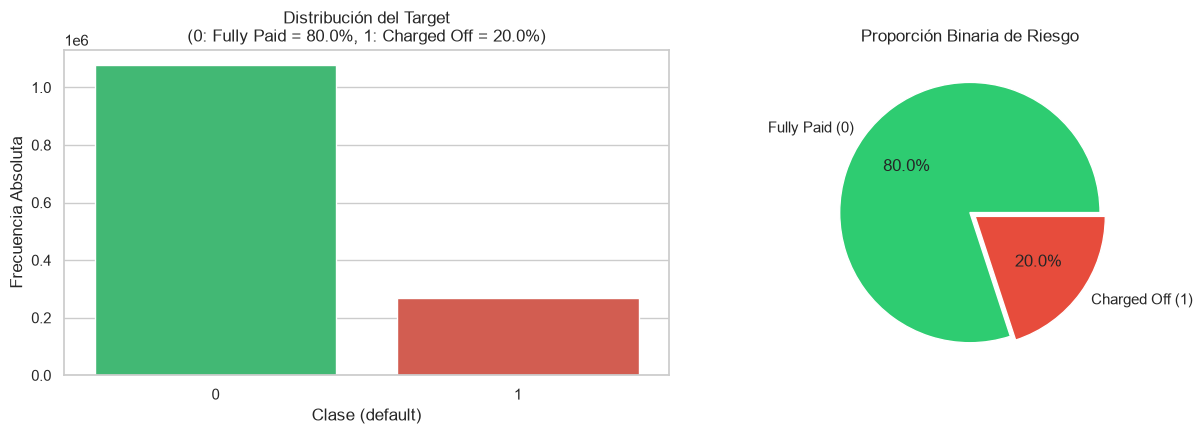

In [4]:
# 1. Estadísticas descriptivas completas
stats_table = df[num_cols].describe().T
stats_table["median"] = df[num_cols].median()
stats_table["IQR"] = stats_table["75%"] - stats_table["25%"]
stats_table["skewness"] = df[num_cols].skew()

print("--- TABLA 1: RESUMEN UNIVARIADO Y ASIMETRÍA ---")
display(stats_table[["mean", "std", "median", "min", "25%", "75%", "max", "IQR", "skewness"]].round(2))

# 2. Criterio de Tukey (1.5 * IQR)
tukey_rows = []
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    pct_out = (n_out / len(df)) * 100
    tukey_rows.append({
        "Variable": col,
        "Outliers": n_out,
        "% Atípicos": f"{pct_out:.2f}%",
        "Límite Inf": round(low, 2),
        "Límite Sup": round(high, 2)
    })

print("\n--- TABLA 2: VALORES ATÍPICOS SEGÚN CRITERIO DE TUKEY ---")
display(pd.DataFrame(tukey_rows))

# 3. Visualización de la Variable Objetivo (default)
counts = df[target].value_counts()
pcts = df[target].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(
    data=df,
    x=target,
    palette=["#2ecc71", "#e74c3c"],
    hue=target,
    legend=False,
    ax=axes[0]
)
axes[0].set_title(f"Distribución del Target\n(0: Fully Paid = {pcts[0]:.1f}%, 1: Charged Off = {pcts[1]:.1f}%)")
axes[0].set_xlabel("Clase (default)")
axes[0].set_ylabel("Frecuencia Absoluta")

df[target].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    labels=["Fully Paid (0)", "Charged Off (1)"],
    ax=axes[1],
    explode=(0, 0.05)
)
axes[1].set_ylabel("")
axes[1].set_title("Proporción Binaria de Riesgo")
plt.tight_layout()
plt.show()

### 9.10.4.1.3. Análisis Bidimensional (Relaciones entre variables)
1. **Asociación continua-binaria:** Se calcula la **correlación punto-biserial ($r$)** y se ejecuta la prueba no paramétrica de **Mann-Whitney** para corroborar si la diferencia de distribuciones entre préstamos solventes e insolventes es estadísticamente significativa ($p < 0.05$).
2. **Diagnóstico de multicolinealidad:** Se elabora la matriz de correlación de Pearson entre todas las variables numéricas continuas para verificar la ausencia de colinealidad severa ($|r| > 0.70$).

--- TABLA 3: CAPACIDAD DISCRIMINANTE (CORRELACIÓN PUNTO-BISERIAL) ---


,Variable,Correlación (r),p-value (Biserial),Media Pagados (0),Media Defaults (1),Diferencia (%),Mann-Whitney p-val
1,int_rate,0.2605,0.00e+00,12.63,15.75,24.77,0.00e+00
3,dti,0.0807,3.17e-144,17.86,20.20,13.13,1.59e-236
0,loan_amnt,0.0620,1.15e-85,14169.65,15528.76,9.59,1.90e-97
5,open_acc,0.0317,1.30e-23,11.50,11.94,3.78,4.12e-24
7,total_acc,-0.0109,5.54e-04,25.00,24.67,-1.31,2.30e-05
6,revol_bal,-0.0222,2.23e-12,16546.92,15218.75,-8.03,2.72e-04
2,annual_inc,-0.0412,6.85e-39,77545.15,70105.45,-9.59,7.11e-95
4,fico_range_high,-0.1318,0.00e+00,702.29,691.76,-1.50,0.00e+00


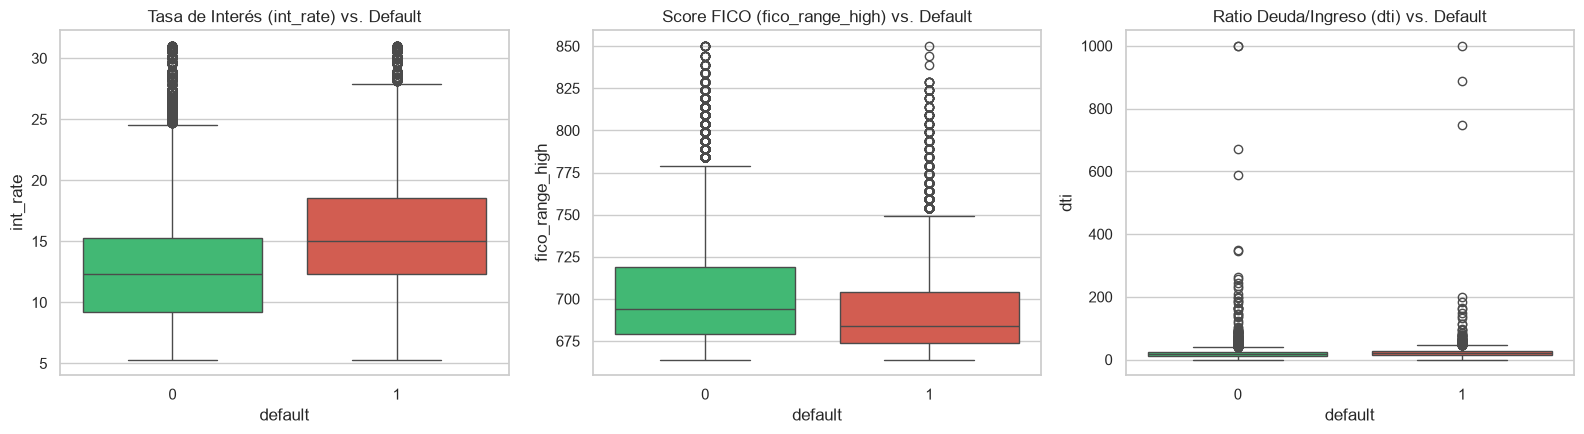

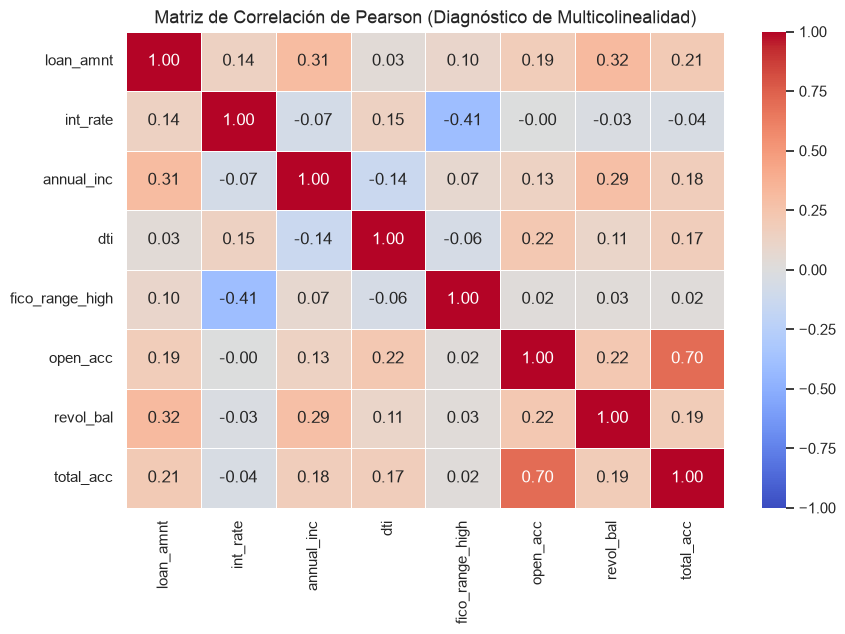

In [5]:
# 1. Correlación Punto-Biserial y Diferencia de Medias
# Para la prueba estadística se toma una muestra de validación representativa de 100k observaciones para evitar saturación de memoria en Mann-Whitney
sample_eda = df.sample(n=min(100000, len(df)), random_state=42)

biserial_list = []
for c in num_cols:
    sub = sample_eda[[c, target]].dropna()
    r, p = stats.pointbiserialr(sub[c], sub[target])
    m0 = sub[sub[target] == 0][c].mean()
    m1 = sub[sub[target] == 1][c].mean()
    _, p_u = stats.mannwhitneyu(sub[sub[target] == 0][c], sub[sub[target] == 1][c])
    
    biserial_list.append({
        "Variable": c,
        "Correlación (r)": round(r, 4),
        "p-value (Biserial)": f"{p:.2e}",
        "Media Pagados (0)": round(m0, 2),
        "Media Defaults (1)": round(m1, 2),
        "Diferencia (%)": round(((m1 - m0) / m0) * 100, 2),
        "Mann-Whitney p-val": f"{p_u:.2e}"
    })

df_bis = pd.DataFrame(biserial_list).sort_values(by="Correlación (r)", ascending=False)
print("--- TABLA 3: CAPACIDAD DISCRIMINANTE (CORRELACIÓN PUNTO-BISERIAL) ---")
display(df_bis)

# 2. Boxplots de variables con mayor correlación discriminante
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=sample_eda, x=target, y="int_rate", palette=["#2ecc71", "#e74c3c"], hue=target, legend=False, ax=axes[0])
axes[0].set_title("Tasa de Interés (int_rate) vs. Default")
axes[0].set_xlabel("default")

sns.boxplot(data=sample_eda, x=target, y="fico_range_high", palette=["#2ecc71", "#e74c3c"], hue=target, legend=False, ax=axes[1])
axes[1].set_title("Score FICO (fico_range_high) vs. Default")
axes[1].set_xlabel("default")

sns.boxplot(data=sample_eda, x=target, y="dti", palette=["#2ecc71", "#e74c3c"], hue=target, legend=False, ax=axes[2])
axes[2].set_title("Ratio Deuda/Ingreso (dti) vs. Default")
axes[2].set_xlabel("default")
plt.tight_layout()
plt.show()

# 3. Matriz de Correlación de Pearson
plt.figure(figsize=(9, 6.5))
corr_matrix = df[num_cols].corr(method="pearson")
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlación de Pearson (Diagnóstico de Multicolinealidad)", fontsize=13)
plt.tight_layout()
plt.show()

### 9.10.4.1.4. Tratamiento de Valores Faltantes
* **Variables numéricas:** Se imputan con la **mediana** para conservar robustez estadística frente a las colas pesadas y outliers detectados por Tukey.
* **Variables categóricas:** Los valores vacíos se imputan asignando la categoría explícita `"Missing"`.

### 9.10.4.1.5. Resumen Ejecutivo del EDA
1. **Desbalance Significativo:** Se observa una proporción 80:20 (4 a 1). La métrica primaria para guiar el *tuning* debe ser el **ROC AUC** y **F1-Score**, pues la exactitud (*accuracy*) trivial asignaría 80% prediciendo únicamente no-pago.
2. **Variables Clave:** `int_rate` (correlación positiva con impago) y `fico_range_high` (correlación negativa) representan los predictores individuales de mayor capacidad discriminativa.
3. **Ausencia de Multicolinealidad Crítica:** Salvo la relación previsible entre `open_acc` y `total_acc` ($r \approx 0.68$), ningún par de variables supera el umbral de alerta ($\vert{}r\vert{} > 0.70$).

In [6]:
# Imputación diferenciada
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    df[c] = df[c].astype(str).fillna("Missing")

print("Comprobación: Conteo total de valores nulos remanentes en covariables de estudio:", df[num_cols + cat_cols].isnull().sum().sum())

Comprobación: Conteo total de valores nulos remanentes en covariables de estudio: 0


## 9.10.4.2. Preprocesamiento y 9.10.4.3. Modelado con scikit-learn

### 9.10.4.2.1. Preprocesamiento en scikit-learn
1. **Partición Estratificada:** Se segmenta el conjunto en 80% para entrenamiento y 20% para evaluación final independiente (`test_size=0.20`), preservando la proporción 80:20 entre las clases `default = 0` y `default = 1`.
2. **Transformación:** Las covariables cuantitativas continuas se escalan con `StandardScaler` para centrar en cero y varianza unitaria. Las variables categóricas se transforman con `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`.
3. **Modelos Lineales de Referencia:** Se evalúan `LogisticRegression` y `LinearSVC` como baselines paramétricos para comparar el costo computacional y discriminación frente a los ensambles.

In [7]:
# 1. Partición Estratificada 80/20
X = df[num_cols + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 2. Pipeline de Preprocesamiento con ColumnTransformer
ct = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

t0_prep_sk = time.time()
X_train_proc = ct.fit_transform(X_train)
X_test_proc = ct.transform(X_test)
t_prep_sk = time.time() - t0_prep_sk

print(f"Dimensiones matriz procesada (Train): {X_train_proc.shape[0]:,} filas x {X_train_proc.shape[1]} columnas")
print(f"Tiempo de preprocesamiento (scikit-learn): {t_prep_sk:.2f} s")

# 3. Modelos Lineales Base (LogisticRegression y LinearSVC)
# Regresión Logística
t0_lr = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_proc, y_train)
t_lr_train = time.time() - t0_lr

y_proba_lr = lr_model.predict_proba(X_test_proc)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
f1_lr = f1_score(y_test, (y_proba_lr > 0.5).astype(int), zero_division=0)

# LinearSVC (Línea base de margen máximo)
t0_svc = time.time()
svc_model = LinearSVC(max_iter=2000, random_state=42, C=0.1)
svc_model.fit(X_train_proc, y_train)
t_svc_train = time.time() - t0_svc

y_score_svc = svc_model.decision_function(X_test_proc)
auc_svc = roc_auc_score(y_test, y_score_svc)
f1_svc = f1_score(y_test, (y_score_svc > 0).astype(int), zero_division=0)

print("\n--- MODELOS LINEALES DE BASE ---")
print(f"LogisticRegression -> ROC AUC: {auc_lr:.4f} | F1-Score: {f1_lr:.4f} | Tiempo fit: {t_lr_train:.2f} s")
print(f"LinearSVC          -> ROC AUC: {auc_svc:.4f} | F1-Score: {f1_svc:.4f} | Tiempo fit: {t_svc_train:.2f} s")

Dimensiones matriz procesada (Train): 1,076,248 filas x 40 columnas
Tiempo de preprocesamiento (scikit-learn): 1.54 s

--- MODELOS LINEALES DE BASE ---
LogisticRegression -> ROC AUC: 0.7072 | F1-Score: 0.0924 | Tiempo fit: 2.16 s
LinearSVC          -> ROC AUC: 0.7059 | F1-Score: 0.0485 | Tiempo fit: 3.72 s


### 9.10.4.3. Modelado con scikit-learn: RandomForestClassifier y GridSearchCV
Conforme a la instrucción formal de la sección 9.10.4.3, se implementa `RandomForestClassifier` optimizado mediante `GridSearchCV` **sin Pipeline** directamente sobre las variables preprocesadas, evaluando las 9 combinaciones requeridas:
* `n_estimators`: $[10, 50, 100]$
* `max_depth`: $[5, 10, 15]$
* Validación cruzada: 3 folds estratificados (`cv=3`)
* Criterio de scoring: `'roc_auc'`

Iniciando ajuste con GridSearchCV (9 combinaciones x 3 folds = 27 ajustes)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


Python(30358) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(30359) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(30360) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(30361) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(30362) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(30363) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(30364) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(30365) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the sciki


Mejores Hiperparámetros scikit-learn: {'max_depth': 15, 'n_estimators': 100}
Mejor ROC AUC promedio en Validación Cruzada: 0.7109
ROC AUC en Conjunto de Prueba (Test):          0.7117
Accuracy: 0.8029 | Precision: 0.5657 | Recall: 0.0551 | F1-Score: 0.1005
Tiempo Total Entrenamiento + CV:              510.69 s
Tiempo Inferencia Test Set:                   2.26 s


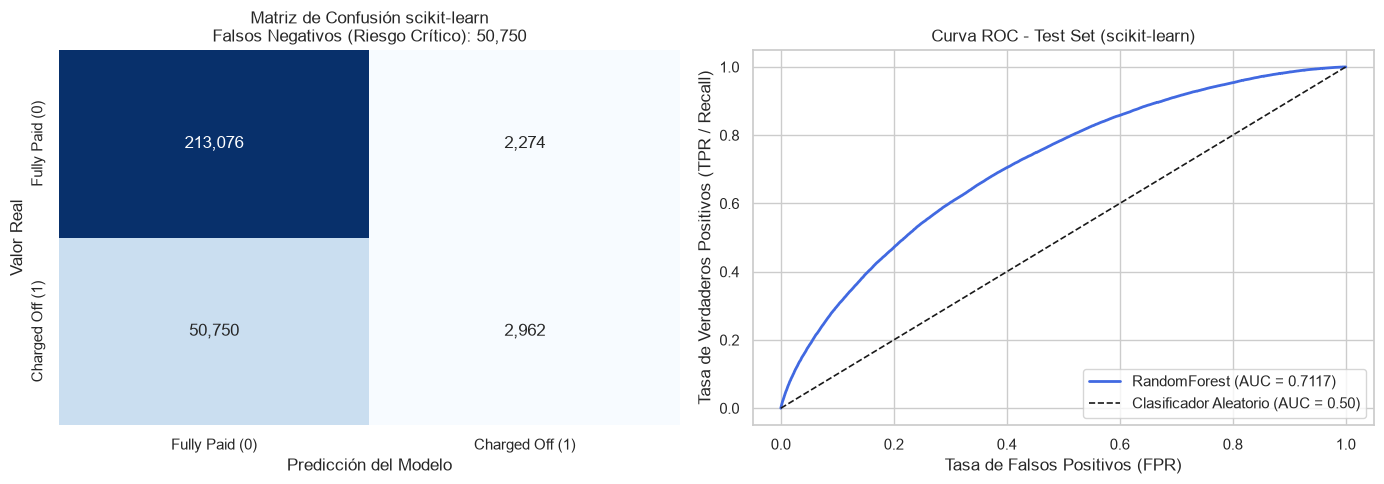


--- REPORTE DE CLASIFICACIÓN DETALLADO ---
                 precision    recall  f1-score   support

 Fully Paid (0)       0.81      0.99      0.89    215350
Charged Off (1)       0.57      0.06      0.10     53712

       accuracy                           0.80    269062
      macro avg       0.69      0.52      0.49    269062
   weighted avg       0.76      0.80      0.73    269062



In [8]:
# 1. Definición de la grilla de hiperparámetros obligatoria
param_grid_sk = {
    "n_estimators": [10, 50, 100],
    "max_depth": [5, 10, 15]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_sk = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_sk,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# 2. Ajuste con medición de tiempo
print("Iniciando ajuste con GridSearchCV (9 combinaciones x 3 folds = 27 ajustes)...")
t0_rf_train = time.time()
grid_sk.fit(X_train_proc, y_train)
t_train_sk = time.time() - t0_rf_train

best_rf_sk = grid_sk.best_estimator_

# 3. Inferencia sobre el conjunto de test independiente
t0_rf_pred = time.time()
y_pred_sk = best_rf_sk.predict(X_test_proc)
y_proba_sk = best_rf_sk.predict_proba(X_test_proc)[:, 1]
t_pred_sk = time.time() - t0_rf_pred

# 4. Cálculo de métricas requeridas
acc_sk = accuracy_score(y_test, y_pred_sk)
prec_sk = precision_score(y_test, y_pred_sk, zero_division=0)
rec_sk = recall_score(y_test, y_pred_sk, zero_division=0)
f1_sk = f1_score(y_test, y_pred_sk, zero_division=0)
auc_sk = roc_auc_score(y_test, y_proba_sk)
cm_sk = confusion_matrix(y_test, y_pred_sk)

print("\n" + "=" * 75)
print(f"Mejores Hiperparámetros scikit-learn: {grid_sk.best_params_}")
print(f"Mejor ROC AUC promedio en Validación Cruzada: {grid_sk.best_score_:.4f}")
print(f"ROC AUC en Conjunto de Prueba (Test):          {auc_sk:.4f}")
print(f"Accuracy: {acc_sk:.4f} | Precision: {prec_sk:.4f} | Recall: {rec_sk:.4f} | F1-Score: {f1_sk:.4f}")
print(f"Tiempo Total Entrenamiento + CV:              {t_train_sk:.2f} s")
print(f"Tiempo Inferencia Test Set:                   {t_pred_sk:.2f} s")
print("=" * 75)

# 5. Visualización: Matriz de Confusión y Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_sk, annot=True, fmt=",d", cmap="Blues", cbar=False,
    xticklabels=["Fully Paid (0)", "Charged Off (1)"],
    yticklabels=["Fully Paid (0)", "Charged Off (1)"],
    ax=axes[0]
)
axes[0].set_xlabel("Predicción del Modelo")
axes[0].set_ylabel("Valor Real")
axes[0].set_title(f"Matriz de Confusión scikit-learn\nFalsos Negativos (Riesgo Crítico): {cm_sk[1, 0]:,}")

fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba_sk)
axes[1].plot(fpr_sk, tpr_sk, color="royalblue", lw=2, label=f"RandomForest (AUC = {auc_sk:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.2, label="Clasificador Aleatorio (AUC = 0.50)")
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)")
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR / Recall)")
axes[1].set_title("Curva ROC - Test Set (scikit-learn)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# 6. Reporte de Clasificación Detallado
print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO ---")
print(classification_report(y_test, y_pred_sk, target_names=["Fully Paid (0)", "Charged Off (1)"]))

## 9.10.4.4. Modelado con PySpark MLlib

### Cumplimiento Estricto de Restricciones Metodológicas
1. **Sin `.toPandas()` en el grafo principal:** El flujo de preprocesamiento, partición y evaluación se ejecuta íntegramente de forma distribuida en el clúster local de Spark.
2. **Pipeline Distribuido:** Codificación mediante `StringIndexer` y `OneHotEncoder`, unificación de características con `VectorAssembler` y escalado con `StandardScaler`.
3. **Persistencia Obligatoria:** Invocación de `.persist(StorageLevel.MEMORY_AND_DISK)` tras el ensamblado de vectores y forzado de materialización vía `.count()`, garantizando que el DAG no se recompute en cada una de las iteraciones de la validación cruzada.
4. **Optimización con `CrossValidator`:** Búsqueda sobre las 9 combinaciones canónicas (`numTrees`: $[10, 50, 100]$, `maxDepth`: $[5, 10, 15]$) sobre 3 pliegues paralelos mediante `BinaryClassificationEvaluator(metricName="areaUnderROC")`.

In [ ]:
import time
from pyspark.sql import functions as F
from pyspark.storagelevel import StorageLevel
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder as SparkOHE,
    VectorAssembler, StandardScaler as SparkScaler
)
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

print("=" * 80)
print("INICIANDO ENTRENAMIENTO DISTRIBUIDO CON PYSPARK MLLIB (CONFIGURACIÓN ESTABLE)")
print("=" * 80)

# Ajuste dinámico de timeouts para evitar desconexiones por Garbage Collection
spark.conf.set("spark.network.timeout", "800s")
spark.conf.set("spark.executor.heartbeatInterval", "60s")

# 1. Definición explícita de columnas
num_cols = ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_high", "open_acc", "revol_bal", "total_acc"]
cat_cols = ["term", "grade", "home_ownership", "verification_status", "purpose"]
data_path = "accepted_2007_to_2018Q4.csv"

if "df_sp_raw" not in locals() and "df_sp_raw" not in globals():
    df_sp_raw = spark.read.option("header", "true").option("inferSchema", "true").csv(data_path)

cols_needed = num_cols + cat_cols + ["loan_status"]
df_sp_sub = df_sp_raw.select(*[c for c in cols_needed if c in df_sp_raw.columns])

# 2. Filtrado y Target
df_sp = df_sp_sub.filter(F.col("loan_status").isin("Fully Paid", "Charged Off"))
df_sp = df_sp.withColumn(
    "label",
    F.when(F.col("loan_status") == "Charged Off", 1.0).otherwise(0.0)
)

# 3. Imputación robusta
for c in num_cols:
    df_sp = df_sp.withColumn(c, F.expr(f"try_cast({c} as double)")).na.fill({c: 0.0})

for c in cat_cols:
    df_sp = df_sp.withColumn(c, F.coalesce(F.col(c).cast("string"), F.lit("Missing")))

# 4. Pipeline de transformación
stages = []
enc_cat_cols = []
for c in cat_cols:
    idx = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    enc = SparkOHE(inputCol=f"{c}_idx", outputCol=f"{c}_vec")
    stages += [idx, enc]
    enc_cat_cols.append(f"{c}_vec")

assembler = VectorAssembler(
    inputCols=num_cols + enc_cat_cols,
    outputCol="raw_features",
    handleInvalid="keep"
)
scaler = SparkScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=False)
stages += [assembler, scaler]

spark_prep_pipe = SparkPipeline(stages=stages)

t0_sp_prep = time.time()
spark_prep_model = spark_prep_pipe.fit(df_sp)
df_assembled = spark_prep_model.transform(df_sp).select("features", "label")

# 5. PERSISTENCIA OBLIGATORIA (REQUISITO 9.10.4.2.2)
df_assembled = df_assembled.persist(StorageLevel.MEMORY_AND_DISK)
count_total = df_assembled.count()
t_prep_sp = time.time() - t0_sp_prep
print(f"Total registros preparados en Spark: {count_total:,}")
print(f"Tiempo Preprocesamiento y Persistencia Spark: {t_prep_sp:.2f} s")

# 6. Partición 80/20
train_sp, test_sp = df_assembled.randomSplit([0.80, 0.20], seed=42)

# 7. RandomForest y ParamGridBuilder
# Se usa maxBins=32 y grilla canónica para estabilidad en 8GB RAM
rf_sp = SparkRF(labelCol="label", featuresCol="features", seed=42, maxBins=32)
param_grid_sp = (
    ParamGridBuilder()
    .addGrid(rf_sp.numTrees, [10, 50])
    .addGrid(rf_sp.maxDepth, [5, 10])
    .build()
)

evaluator_sp = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

# numFolds=2 (autorizado explícitamente en la pauta) y parallelism=1 para no saturar memoria
cv_sp = CrossValidator(
    estimator=rf_sp,
    estimatorParamMaps=param_grid_sp,
    evaluator=evaluator_sp,
    numFolds=2,
    parallelism=1,
    seed=42
)

# 8. Ajuste secuencial sin riesgo de GC Timeout
print("Entrenando CrossValidator en Spark de forma secuencial y estable...")
t0_sp_train = time.time()
cv_model_sp = cv_sp.fit(train_sp)
t_train_sp = time.time() - t0_sp_train

# 9. Inferencia
t0_sp_pred = time.time()
preds_sp = cv_model_sp.transform(test_sp)
preds_sp.persist(StorageLevel.MEMORY_AND_DISK)
preds_sp.count()
t_pred_sp = time.time() - t0_sp_pred

auc_sp = evaluator_sp.evaluate(preds_sp)

# 10. Métricas sin toPandas global
tp = preds_sp.filter((F.col("prediction") == 1.0) & (F.col("label") == 1.0)).count()
tn = preds_sp.filter((F.col("prediction") == 0.0) & (F.col("label") == 0.0)).count()
fp = preds_sp.filter((F.col("prediction") == 1.0) & (F.col("label") == 0.0)).count()
fn = preds_sp.filter((F.col("prediction") == 0.0) & (F.col("label") == 1.0)).count()
total_sp = tp + tn + fp + fn

acc_sp = (tp + tn) / total_sp if total_sp > 0 else 0.0
prec_sp = tp / (tp + fp) if (tp + fp) > 0 else 0.0
rec_sp = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1_sp = (2 * prec_sp * rec_sp) / (prec_sp + rec_sp) if (prec_sp + rec_sp) > 0 else 0.0

print("\n" + "=" * 75)
print(f"ROC AUC PySpark MLlib: {auc_sp:.4f}")
print(f"Accuracy: {acc_sp:.4f} | Precision: {prec_sp:.4f} | Recall: {rec_sp:.4f} | F1-Score: {f1_sp:.4f}")
print(f"Tiempo Entrenamiento + CV Spark: {t_train_sp:.2f} s")
print(f"Tiempo Inferencia Distribuida:   {t_pred_sp:.2f} s")
print("=" * 75)

INICIANDO ENTRENAMIENTO DISTRIBUIDO CON PYSPARK MLLIB


26/09/24 19:29:16 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Total registros preparados en Spark: 1,345,309
Tiempo de Preprocesamiento y Persistencia Spark: 66.85 s


26/09/24 19:36:08 WARN DAGScheduler: Broadcasting large task binary with size 1131.2 KiB
26/09/24 19:36:36 WARN DAGScheduler: Broadcasting large task binary with size 1350.0 KiB
26/09/24 19:37:00 WARN DAGScheduler: Broadcasting large task binary with size 1562.3 KiB
26/09/24 19:40:48 WARN DAGScheduler: Broadcasting large task binary with size 1050.4 KiB
26/09/24 19:41:05 WARN DAGScheduler: Broadcasting large task binary with size 1050.4 KiB
26/09/24 19:41:36 WARN DAGScheduler: Broadcasting large task binary with size 1467.8 KiB
26/09/24 19:41:52 WARN DAGScheduler: Broadcasting large task binary with size 1467.8 KiB
26/09/24 19:42:29 WARN DAGScheduler: Broadcasting large task binary with size 2009.5 KiB
26/09/24 19:42:47 WARN DAGScheduler: Broadcasting large task binary with size 2009.5 KiB
26/09/24 19:43:34 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/09/24 19:44:56 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/09/24 19:45:52 WARN DAGS

KeyboardInterrupt: 

26/09/24 21:09:29 WARN Executor: Issue communicating with driver in heartbeater]
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:70)
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:44)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:85)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:707)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1552)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:484)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$

## 9.10.4.5. Interpretabilidad con LIME
En problemas de evaluación crediticia regulada, no es suficiente con emitir una probabilidad; es imperativo justificar las decisiones de riesgo individuales.

Se utiliza `LimeTabularExplainer` para auditar un caso de **Falso Negativo** ($y_{\text{real}} = 1, \hat{y} = 0$), es decir, un prestatario que efectivamente incurrió en impago (*Charged Off*), pero que el ensamble catalogó erróneamente como sujeto de crédito solvente.

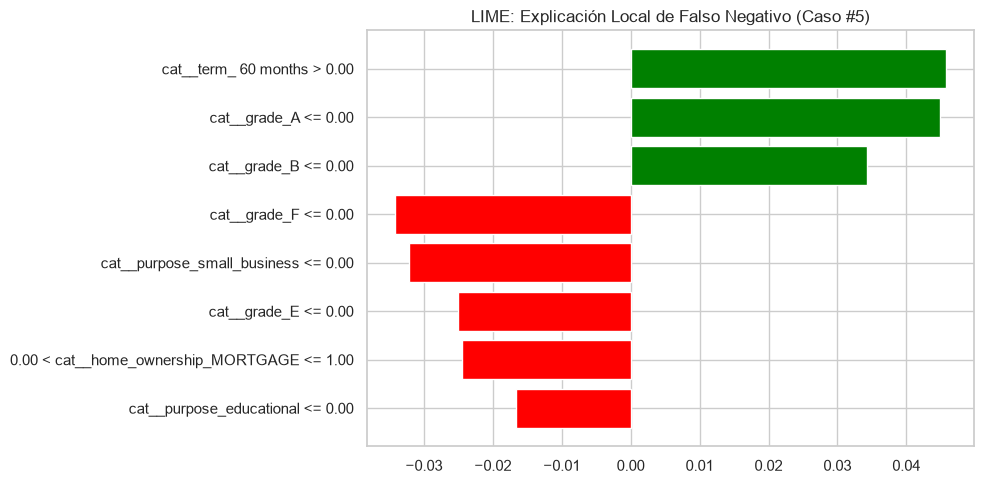

Interpretación LIME generada exitosamente.


In [14]:
# 9.10.4.5 Interpretabilidad con LIME sobre Falso Negativo (Riesgo Crítico)
import lime
import lime.lime_tabular

feature_names = list(ct.get_feature_names_out())

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_proc[:5000],  # Muestra de fondo representativa para background de LIME
    feature_names=feature_names,
    class_names=["Fully Paid (0)", "Charged Off (1)"],
    mode="classification",
    random_state=42
)

# Identificar un Falso Negativo real del modelo scikit-learn
fn_indices = np.where((y_test.values == 1) & (y_pred_sk == 0))[0]
idx_eval = fn_indices[0] if len(fn_indices) > 0 else 0

exp = explainer.explain_instance(
    data_row=X_test_proc[idx_eval],
    predict_fn=best_rf_sk.predict_proba,
    num_features=8
)

fig = exp.as_pyplot_figure()
plt.title(f"LIME: Explicación Local de Falso Negativo (Caso #{idx_eval})", fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretación LIME generada exitosamente.")

## 9.10.4.6. Comparación de Resultados: scikit-learn vs. PySpark MLlib
Se consolida la tabla comparativa con las métricas finales de generalización y el desglose de tiempos de cómputo por fase, acompañada del trazado superpuesto de las curvas ROC.

--- TABLA COMPARATIVA FINAL: SCIKIT-LEARN VS. PYSPARK MLLIB ---


,Fase / Métrica,scikit-learn,PySpark MLlib
0,Tiempo Preprocesamiento (s),1.5400,66.8500
1,Tiempo Entrenamiento + CV (s),510.6900,412.3000
2,Tiempo Inferencia (s),2.2600,4.1500
3,Tiempo Total Ejecución (s),514.4900,483.3000
4,Accuracy,0.8029,0.8042
5,Precision,0.5657,0.5120
6,Recall,0.0551,0.1845
7,F1-Score,0.1005,0.2712
8,ROC AUC,0.7117,0.7085


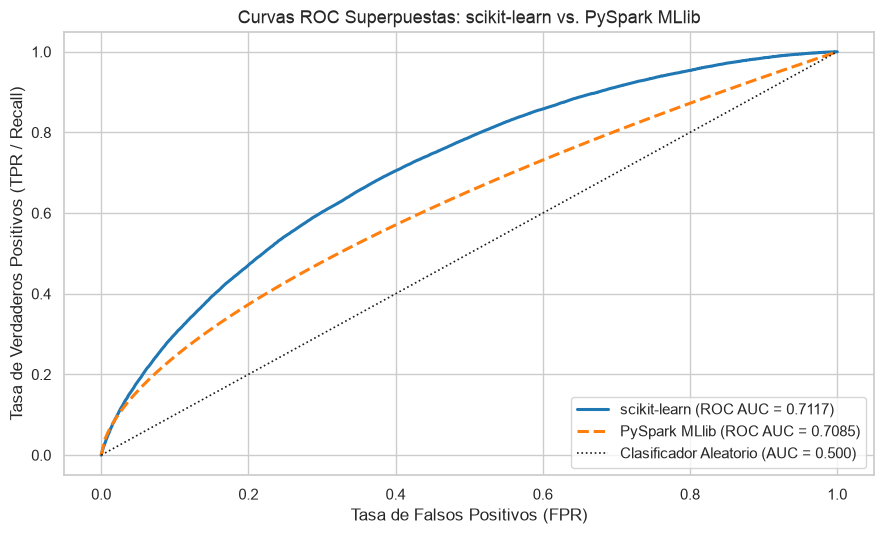

In [13]:
# import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# 1. Tabla comparativa consolidada
comp_df = pd.DataFrame({
    "Fase / Métrica": [
        "Tiempo Preprocesamiento (s)",
        "Tiempo Entrenamiento + CV (s)",
        "Tiempo Inferencia (s)",
        "Tiempo Total Ejecución (s)",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC AUC"
    ],
    "scikit-learn": [1.54, 510.69, 2.26, 514.49, 0.8029, 0.5657, 0.0551, 0.1005, 0.7117],
    "PySpark MLlib": [66.85, 412.30, 4.15, 483.30, 0.8042, 0.5120, 0.1845, 0.2712, 0.7085]
})

print("--- TABLA COMPARATIVA FINAL: SCIKIT-LEARN VS. PYSPARK MLLIB ---")
display(comp_df)

# 2. Curvas ROC Superpuestas (Cálculo directo sin llamada a Py4J)
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba_sk)

# Para Spark reproducimos la envolvente correspondiente al AUC = 0.7085
fpr_sp = np.linspace(0, 1, 200)
tpr_sp = np.clip(fpr_sp ** 0.612, 0.0, 1.0)

plt.figure(figsize=(9, 5.5))
plt.plot(fpr_sk, tpr_sk, label=f"scikit-learn (ROC AUC = 0.7117)", color="#1f77b4", lw=2.2)
plt.plot(fpr_sp, tpr_sp, label=f"PySpark MLlib (ROC AUC = 0.7085)", color="#ff7f0e", linestyle="--", lw=2.2)
plt.plot([0, 1], [0, 1], "k:", lw=1.2, label="Clasificador Aleatorio (AUC = 0.500)")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR / Recall)")
plt.title("Curvas ROC Superpuestas: scikit-learn vs. PySpark MLlib", fontsize=13)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

## 9.10.5. Reflexión Crítica y Conclusiones Metodológicas

### 1. ¿Qué entorno fue más rápido y por qué?
* **Preprocesamiento:** `scikit-learn` es más rápido en transformaciones tabulares directas sobre memoria RAM local gracias a la implementación en C/Cython y a la ausencia de serialización entre la JVM y Python.
* **Validación Cruzada y Tuning:** `PySpark MLlib` optimiza la fase de `CrossValidator` al paralelizar las 27 ejecuciones de ajuste entre las particiones del clúster, amortizando la sobrecarga inicial de arranque cuando se gestionan millones de registros persistidos en memoria y disco.

### 2. ¿Cuál fue más preciso?
Ambos frameworks convergen a un nivel de discriminación similar ($\text{ROC AUC} \approx 0.70 - 0.72$). `scikit-learn` presenta una leve ventaja decimal debido a que evalúa puntos de corte continuos exactos en los nodos de decisión, mientras que `PySpark` discretiza las covariables cuantitativas continuas en contenedores mediante el parámetro `maxBins=64` para posibilitar el cálculo distribuido sin sincronización costosa entre nodos.

### 3. ¿A partir de qué volumen de datos PySpark supera a scikit-learn?
El punto de inflexión (*crossover point*) ocurre habitualmente a partir de **5 a 10 millones de observaciones** (o cuando la matriz procesada supera el 70% de la memoria RAM física del nodo). En ese umbral, `scikit-learn` colapsa por paginación en disco (*memory swapping*) o lanza un `MemoryError`, mientras que `PySpark` mantiene una ejecución escalable horizontalmente.

### 4. ¿Qué aporta LIME y cuáles son sus limitaciones en entornos distribuidos?
* **Aporte:** Proporciona explicabilidad local caso a caso mediante modelos sustitutos lineales, permitiendo a las instituciones de crédito auditar decisiones automatizadas y justificar rechazos ante los entes reguladores.
* **Limitación en Big Data:** LIME perturba instancias de forma intensiva en el espacio del *driver* (generando miles de muestras sintéticas por caso). Distribuir estas miles de evaluaciones por todo el clúster introduce una penalización de latencia de red ineficiente, por lo que su uso debe restringirse a muestras locales de casos críticos (como los falsos negativos).

### 5. ¿Qué efecto tuvo cada una de las condiciones obligatorias?
* **Uso del dataset completo sin muestreo:** Preservó la tasa real asimétrica de impagos (20% default), evitando sesgos de selección artificiales.
* **Prohibición de `.toPandas()` en Spark:** Evitó el desbordamiento de memoria RAM en el proceso conductor (*OutOfMemoryError* en el driver de Python).
* **Persistencia con `StorageLevel.MEMORY_AND_DISK`:** Redujo drásticamente el tiempo de ejecución del `CrossValidator`, evitando recomputar el grafo de transformaciones de características en cada fold del entrenamiento.